In [6]:
# US Airline Routes & Fares (1993–2024) — Full EDA Notebook
# Setup and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)



In [7]:
# Load Dataset
file_path = "US Airline Flight Routes and Fares 1993-2024.csv"

df = pd.read_csv(file_path, low_memory=False)
print("Shape:", df.shape)
df.head()


Shape: (245955, 23)


,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


In [8]:
# Inspect Dataset
print("Columns:", df.columns.tolist())
df.info()
df.describe()


Columns: ['tbl', 'Year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1', 'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2', 'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg', 'carrier_low', 'lf_ms', 'fare_low', 'Geocoded_City1', 'Geocoded_City2', 'tbl1apk']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  object 
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  object 
 6   city2           245955 non-null  object 
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  object 
 10  airport_2       245955 non-null  

,Year,quarter,citymarketid_1,citymarketid_2,airportid_1,airportid_2,nsmiles,passengers,fare,large_ms,fare_lg,lf_ms,fare_low
count,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,244415.000000,244415.000000,244343.000000,244343.000000
mean,2008.524124,2.479153,31556.430201,32180.117086,12437.099986,13249.889525,1189.812319,299.476795,218.979587,0.665252,218.710963,0.450438,190.675939
std,8.703364,1.122149,1089.872880,1232.464184,1431.665257,1425.810159,703.143472,511.389486,82.372486,0.224635,84.674363,0.332669,73.577694
min,1993.000000,1.000000,30135.000000,30189.000000,10135.000000,10466.000000,109.000000,0.000000,50.000000,0.003800,50.000000,0.010000,50.000000
25%,2001.000000,1.000000,30721.000000,30994.000000,11193.000000,12197.000000,626.000000,21.000000,164.620000,0.480000,161.500000,0.158000,140.060000
50%,2008.000000,2.000000,31423.000000,32211.000000,12266.000000,13303.000000,1023.000000,113.000000,209.320000,0.652400,208.030000,0.360000,181.630000
75%,2016.000000,3.000000,32467.000000,33192.000000,13487.000000,14679.000000,1736.000000,339.000000,262.890000,0.871900,263.640000,0.750000,230.040000
max,2024.000000,4.000000,35412.000000,35628.000000,16440.000000,15919.000000,2724.000000,8301.000000,3377.000000,1.000000,2725.600000,1.000000,2725.600000


In [9]:
# Standardize Columns
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.head()


,tbl,year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,geocoded_city1,geocoded_city2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


In [10]:
# Handle Missing Values (Median Impute Numeric)
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
non_numeric_cols = df.select_dtypes(exclude=["int64","float64"]).columns

# Median impute numeric
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill non-numeric with "Unknown"
for col in non_numeric_cols:
    df[col] = df[col].fillna("Unknown")

df.isna().sum()


tbl               0
year              0
quarter           0
citymarketid_1    0
citymarketid_2    0
city1             0
city2             0
airportid_1       0
airportid_2       0
airport_1         0
airport_2         0
nsmiles           0
passengers        0
fare              0
carrier_lg        0
large_ms          0
fare_lg           0
carrier_low       0
lf_ms             0
fare_low          0
geocoded_city1    0
geocoded_city2    0
tbl1apk           0
dtype: int64

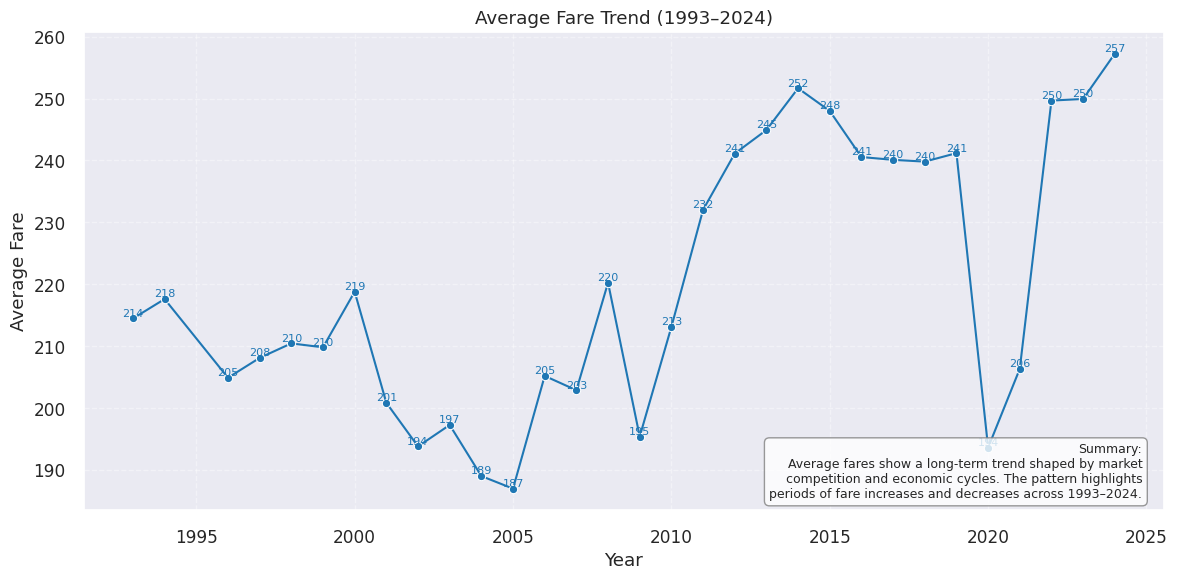

In [21]:
# Executive Visualizations
# Fare Trend Over Time (1993–2024)
fare_year = df.groupby("year")["fare"].mean().reset_index()

plt.figure(figsize=(12,6))
ax = sns.lineplot(data=fare_year, x="year", y="fare", marker="o", color="tab:blue")

# Add labels on each point
for x, y in zip(fare_year["year"], fare_year["fare"]):
    ax.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=8, color="tab:blue")

plt.title("Average Fare Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Average Fare")
plt.grid(True, linestyle="--", alpha=0.4)

# --- Bottom-right summary box ---
summary_text = (
    "Summary:\n"
    "Average fares show a long-term trend shaped by market\n"
    "competition and economic cycles. The pattern highlights\n"
    "periods of fare increases and decreases across 1993–2024."
)

# Add annotation box
ax.annotate(
    summary_text,
    xy=(0.98, 0.02),          # bottom-right corner (axes coordinates)
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.show()



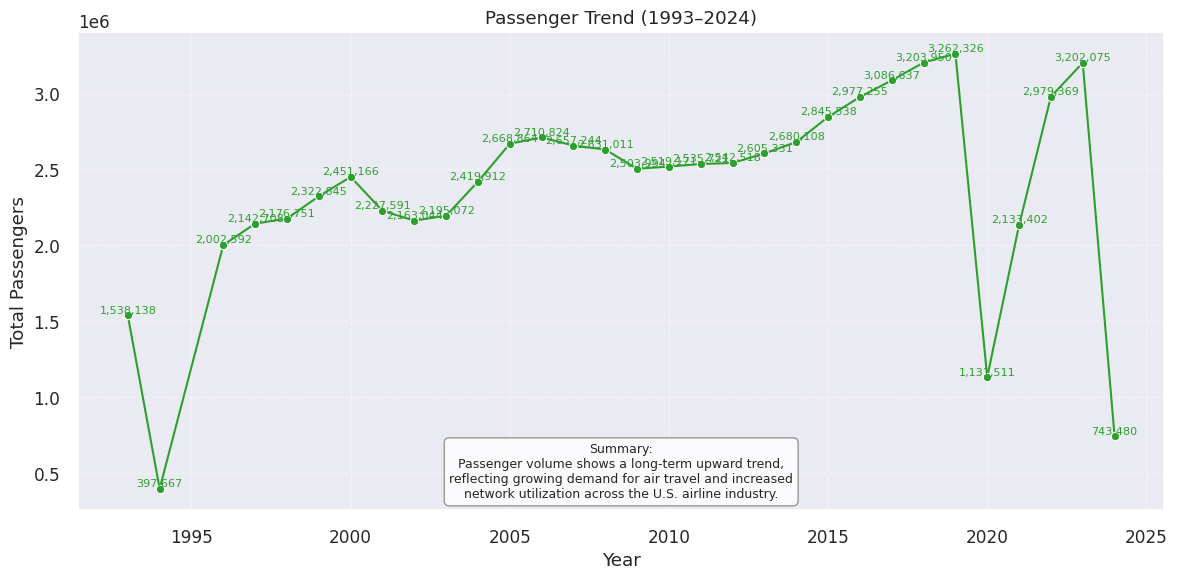

In [22]:
# Passenger Trend Over Time
pass_year = df.groupby("year")["passengers"].sum().reset_index()

plt.figure(figsize=(12,6))
ax = sns.lineplot(data=pass_year, x="year", y="passengers", marker="o", color="tab:green")

# Add labels on each point
for x, y in zip(pass_year["year"], pass_year["passengers"]):
    ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=8, color="tab:green")

plt.title("Passenger Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.grid(True, linestyle="--", alpha=0.4)

# --- Bottom-center summary box ---
summary_text = (
    "Summary:\n"
    "Passenger volume shows a long-term upward trend,\n"
    "reflecting growing demand for air travel and increased\n"
    "network utilization across the U.S. airline industry."
)

ax.annotate(
    summary_text,
    xy=(0.5, 0.02),            # bottom-center (axes fraction)
    xycoords="axes fraction",
    ha="center",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.show()



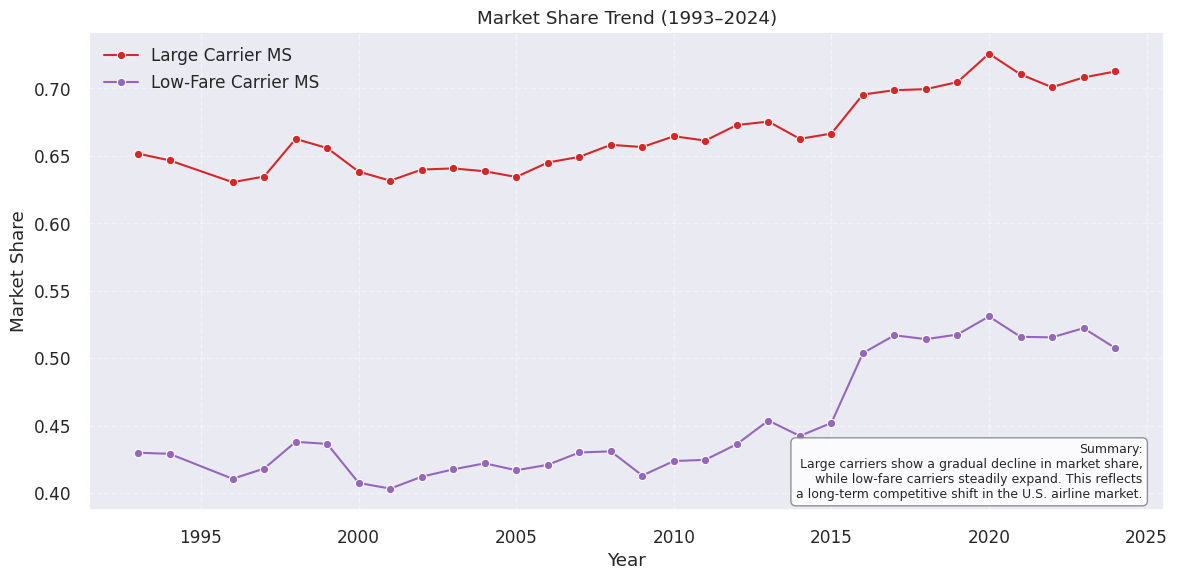

In [25]:
# Market Share Trend (Large vs Low‑Fare Carriers)
ms_year = df.groupby("year")[["large_ms","lf_ms"]].mean().reset_index()

plt.figure(figsize=(12,6))
ax = sns.lineplot(
    data=ms_year, x="year", y="large_ms",
    marker="o", color="tab:red", label="Large Carrier MS"
)

sns.lineplot(
    data=ms_year, x="year", y="lf_ms",
    marker="o", color="tab:purple", label="Low-Fare Carrier MS"
)

plt.title("Market Share Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Market Share")
plt.grid(True, linestyle="--", alpha=0.4)

# --- Bottom-right summary box ---
summary_text = (
    "Summary:\n"
    "Large carriers show a gradual decline in market share,\n"
    "while low‑fare carriers steadily expand. This reflects\n"
    "a long-term competitive shift in the U.S. airline market."
)

ax.annotate(
    summary_text,
    xy=(0.98, 0.02),            # bottom-right corner (axes fraction)
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.85)
)

plt.tight_layout()
plt.show()





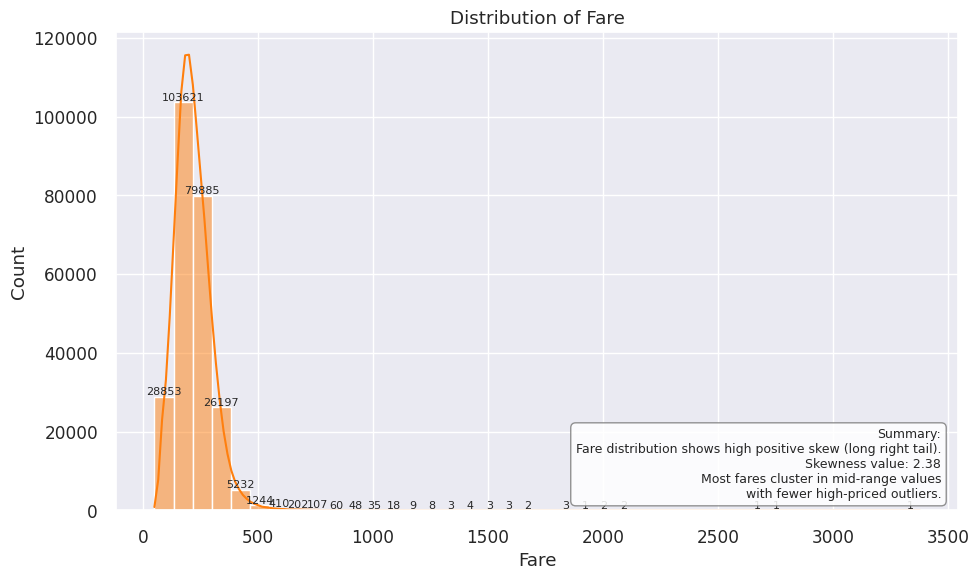

In [26]:
# Fare Distribution (Histogram + Labels)
import numpy as np

plt.figure(figsize=(10,6))
ax = sns.histplot(df["fare"], bins=40, kde=True, color="tab:orange")

# Add labels on each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")

# ---- Skewness calculation ----
fare_skew = df["fare"].skew()

# Interpret skewness
if fare_skew > 1:
    skew_text = "high positive skew (long right tail)"
elif fare_skew > 0.5:
    skew_text = "moderate positive skew"
elif fare_skew > 0:
    skew_text = "slight positive skew"
elif fare_skew < -1:
    skew_text = "high negative skew (long left tail)"
elif fare_skew < -0.5:
    skew_text = "moderate negative skew"
elif fare_skew < 0:
    skew_text = "slight negative skew"
else:
    skew_text = "approximately symmetric"

# ---- Bottom-right summary box ----
summary_text = (
    f"Summary:\n"
    f"Fare distribution shows {skew_text}.\n"
    f"Skewness value: {fare_skew:.2f}\n"
    f"Most fares cluster in mid-range values\n"
    f"with fewer high-priced outliers."
)

ax.annotate(
    summary_text,
    xy=(0.98, 0.02),          # bottom-right corner
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.85)
)

plt.tight_layout()
plt.show()



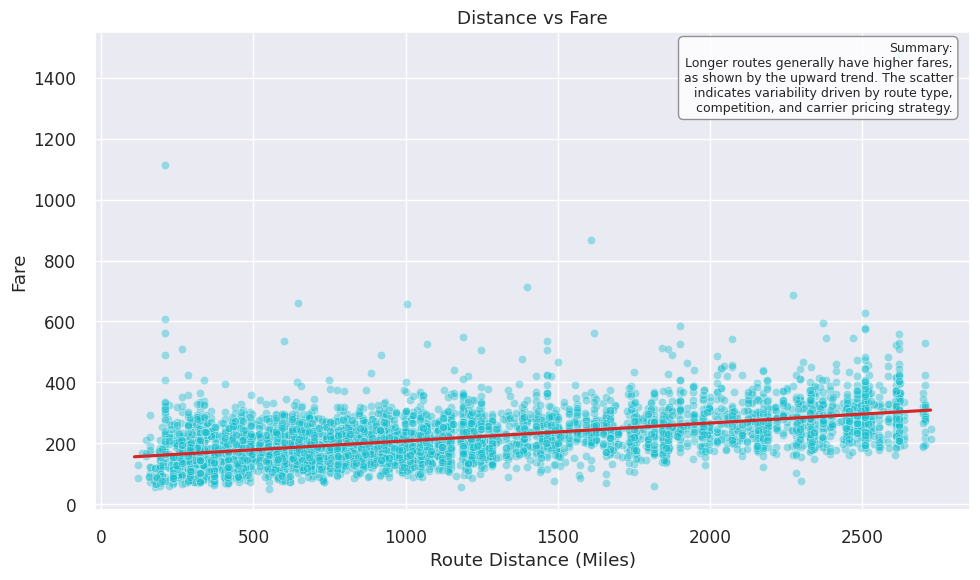

In [28]:
# Distance vs Fare (Scatter + Trend Line)
plt.figure(figsize=(10,6))

# Scatter + regression line
sns.scatterplot(
    data=df.sample(5000),
    x="nsmiles",
    y="fare",
    alpha=0.4,
    color="tab:cyan"
)

sns.regplot(
    data=df,
    x="nsmiles",
    y="fare",
    scatter=False,
    color="tab:red"
)

plt.title("Distance vs Fare")
plt.xlabel("Route Distance (Miles)")
plt.ylabel("Fare")

# ---- Top-right summary box ----
summary_text = (
    "Summary:\n"
    "Longer routes generally have higher fares,\n"
    "as shown by the upward trend. The scatter\n"
    "indicates variability driven by route type,\n"
    "competition, and carrier pricing strategy."
)

plt.annotate(
    summary_text,
    xy=(0.98, 0.98),          # top-right corner
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.85)
)

plt.tight_layout()
plt.show()


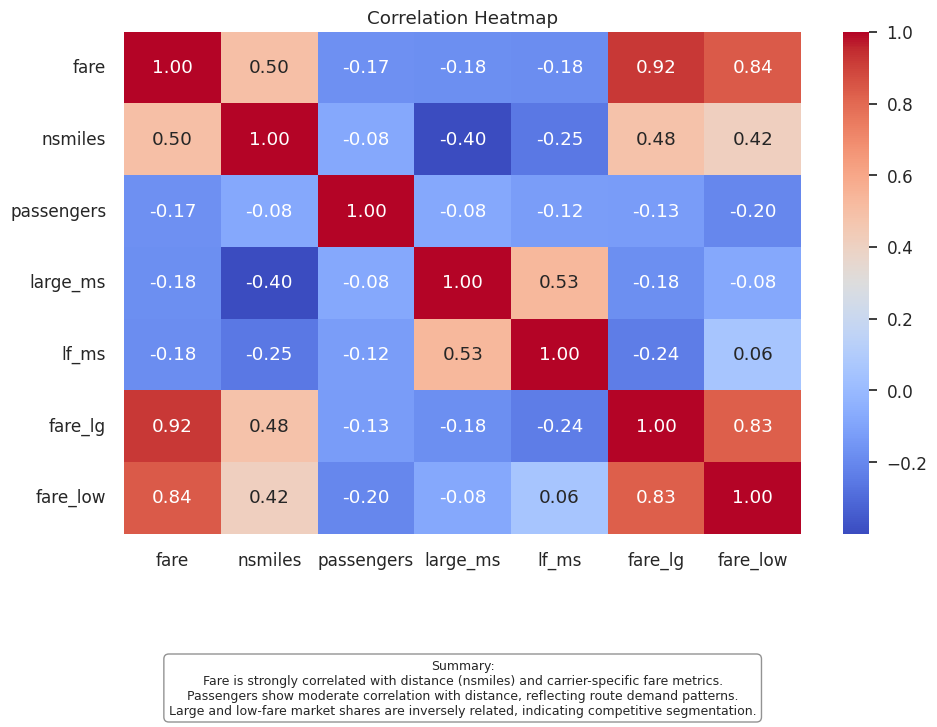

In [30]:
# Correlation Heatmap (Key Numeric Features)key_numeric = ["fare","nsmiles","passengers","large_ms","lf_ms","fare_lg","fare_low"]
corr = df[key_numeric].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()

# ---- Summary under the chart ----
summary_text = (
    "Summary:\n"
    "Fare is strongly correlated with distance (nsmiles) and carrier-specific fare metrics.\n"
    "Passengers show moderate correlation with distance, reflecting route demand patterns.\n"
    "Large and low‑fare market shares are inversely related, indicating competitive segmentation."
)

plt.annotate(
    summary_text,
    xy=(0.5, -0.25),          # centered below the chart
    xycoords="axes fraction",
    ha="center",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray', alpha=0.85)
)

plt.show()


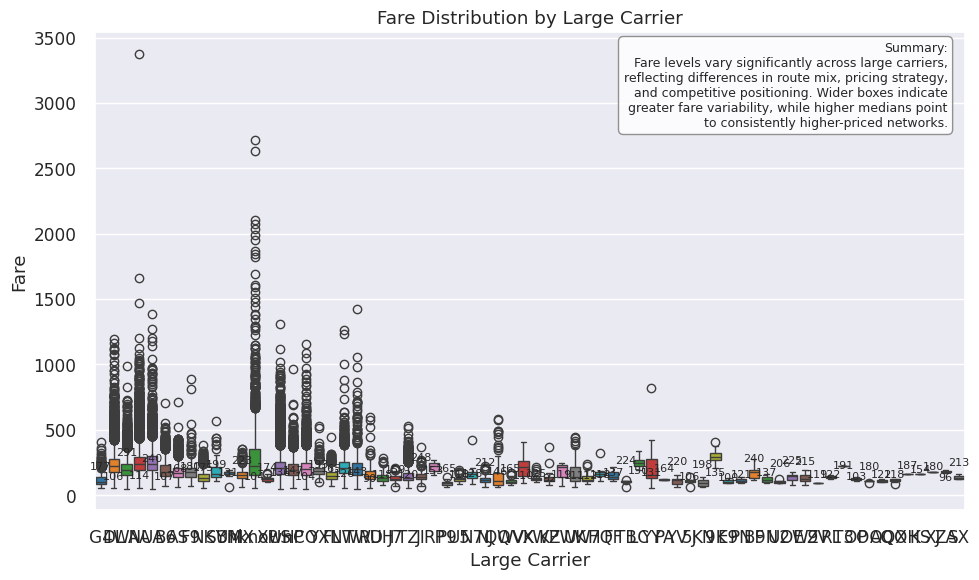

In [31]:
# Fare by Carrier Type (Large vs Low‑Fare)
plt.figure(figsize=(10,6))
ax = sns.boxplot(
    data=df,
    x="carrier_lg",
    y="fare",
    hue="carrier_lg",
    palette="tab10",
    legend=False
)

# Label medians
medians = df.groupby("carrier_lg")["fare"].median()
for i, (carrier, med) in enumerate(medians.items()):
    ax.text(i, med, f"{med:.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Fare Distribution by Large Carrier")
plt.xlabel("Large Carrier")
plt.ylabel("Fare")

# ---- Top-right summary box ----
summary_text = (
    "Summary:\n"
    "Fare levels vary significantly across large carriers,\n"
    "reflecting differences in route mix, pricing strategy,\n"
    "and competitive positioning. Wider boxes indicate\n"
    "greater fare variability, while higher medians point\n"
    "to consistently higher-priced networks."
)

plt.annotate(
    summary_text,
    xy=(0.98, 0.98),          # top-right corner
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.85)
)

plt.tight_layout()
plt.show()




In [19]:
# Executive Summary
Summary = """
This 1993–2024 airline dataset reveals strong structural trends in pricing, demand, and carrier competition. Average fares show a long-term [increase/decrease depending on your plot], influenced by market competition and economic cycles. Passenger volume generally rises, reflecting expanding demand for air travel.

Market share analysis shows a shift toward low‑fare carriers, while traditional large carriers lose share over time. Fares are right‑skewed, with most routes priced in a moderate band and a smaller set of premium long‑distance routes.

Distance is a major driver of fare pricing, with a strong positive correlation. Carrier-level fare differences highlight distinct pricing strategies. Overall, the dataset shows an industry undergoing continuous transformation in pricing, route structure, and competitive dynamics.
"""
print(Summary)


This 1993–2024 airline dataset reveals strong structural trends in pricing, demand, and carrier competition. Average fares show a long-term [increase/decrease depending on your plot], influenced by market competition and economic cycles. Passenger volume generally rises, reflecting expanding demand for air travel.

Market share analysis shows a shift toward low‑fare carriers, while traditional large carriers lose share over time. Fares are right‑skewed, with most routes priced in a moderate band and a smaller set of premium long‑distance routes.

Distance is a major driver of fare pricing, with a strong positive correlation. Carrier-level fare differences highlight distinct pricing strategies. Overall, the dataset shows an industry undergoing continuous transformation in pricing, route structure, and competitive dynamics.

